In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

# Verificar si hay GPU disponible
dispositivo = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Dispositivo: {dispositivo}")

# Clases
clases = ['airplane', 'automobile', 'bird', 'cat', 'deer',
          'dog', 'frog', 'horse', 'ship', 'truck']

# Cargar dataset
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

train_dataset = torchvision.datasets.CIFAR10(root='./data', train=True, download=False, transform=transform)
test_dataset = torchvision.datasets.CIFAR10(root='./data', train=False, download=False, transform=transform)

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=64, shuffle=False)

print(f"Batches de entrenamiento: {len(train_loader)}")
print(f"Batches de prueba: {len(test_loader)}")

Dispositivo: cpu


c:\Users\diego\OneDrive\Desktop\visionShop\.venv\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Batches de entrenamiento: 782
Batches de prueba: 157


In [5]:
class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()
        
        # Bloque convolucional 1
        self.conv1 = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )
        
        # Bloque convolucional 2
        self.conv2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )
        
        # Bloque convolucional 3
        self.conv3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )
        
        # Capas fully connected
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 4 * 4, 512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, 10)
        )
    
    def forward(self, x):
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.conv3(x)
        x = self.fc(x)
        return x

# Crear modelo
modelo = CNN().to(dispositivo)
print(modelo)
print(f"\nParámetros totales: {sum(p.numel() for p in modelo.parameters()):,}")

CNN(
  (conv1): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv3): Sequential(
    (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (fc): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=2048, out_features=512, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.5, inplace=False)
    (4): Linear(in_features=512, out_features=10, bias=True)
  )
)

Parámetros totales: 1,147,466


In [6]:
# Definir loss y optimizador
criterio = nn.CrossEntropyLoss()
optimizador = optim.Adam(modelo.parameters(), lr=0.001)

# Entrenamiento
EPOCAS = 10
historial = {"train_loss": [], "train_acc": [], "test_acc": []}

for epoca in range(EPOCAS):
    modelo.train()
    loss_total = 0
    correctas = 0
    total = 0
    
    for imagenes, etiquetas in train_loader:
        imagenes, etiquetas = imagenes.to(dispositivo), etiquetas.to(dispositivo)
        
        optimizador.zero_grad()
        salidas = modelo(imagenes)
        loss = criterio(salidas, etiquetas)
        loss.backward()
        optimizador.step()
        
        loss_total += loss.item()
        _, predicciones = salidas.max(1)
        correctas += predicciones.eq(etiquetas).sum().item()
        total += etiquetas.size(0)
    
    train_acc = 100 * correctas / total
    train_loss = loss_total / len(train_loader)
    
    # Evaluar en test
    modelo.eval()
    correctas_test = 0
    total_test = 0
    with torch.no_grad():
        for imagenes, etiquetas in test_loader:
            imagenes, etiquetas = imagenes.to(dispositivo), etiquetas.to(dispositivo)
            salidas = modelo(imagenes)
            _, predicciones = salidas.max(1)
            correctas_test += predicciones.eq(etiquetas).sum().item()
            total_test += etiquetas.size(0)
    
    test_acc = 100 * correctas_test / total_test
    
    historial["train_loss"].append(train_loss)
    historial["train_acc"].append(train_acc)
    historial["test_acc"].append(test_acc)
    
    print(f"Época {epoca+1}/{EPOCAS} | Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | Test Acc: {test_acc:.2f}%")

print("\n✓ Entrenamiento completado")

Época 1/10 | Loss: 1.4422 | Train Acc: 47.31% | Test Acc: 60.59%
Época 2/10 | Loss: 1.0311 | Train Acc: 63.45% | Test Acc: 69.36%
Época 3/10 | Loss: 0.8510 | Train Acc: 69.96% | Test Acc: 71.75%
Época 4/10 | Loss: 0.7314 | Train Acc: 74.40% | Test Acc: 74.60%
Época 5/10 | Loss: 0.6424 | Train Acc: 77.39% | Test Acc: 75.70%
Época 6/10 | Loss: 0.5613 | Train Acc: 80.22% | Test Acc: 75.48%
Época 7/10 | Loss: 0.5016 | Train Acc: 82.30% | Test Acc: 77.07%
Época 8/10 | Loss: 0.4438 | Train Acc: 84.33% | Test Acc: 76.60%
Época 9/10 | Loss: 0.3974 | Train Acc: 85.86% | Test Acc: 77.01%
Época 10/10 | Loss: 0.3560 | Train Acc: 87.26% | Test Acc: 76.23%

✓ Entrenamiento completado


✓ Modelo guardado en models/cnn_scratch.pth


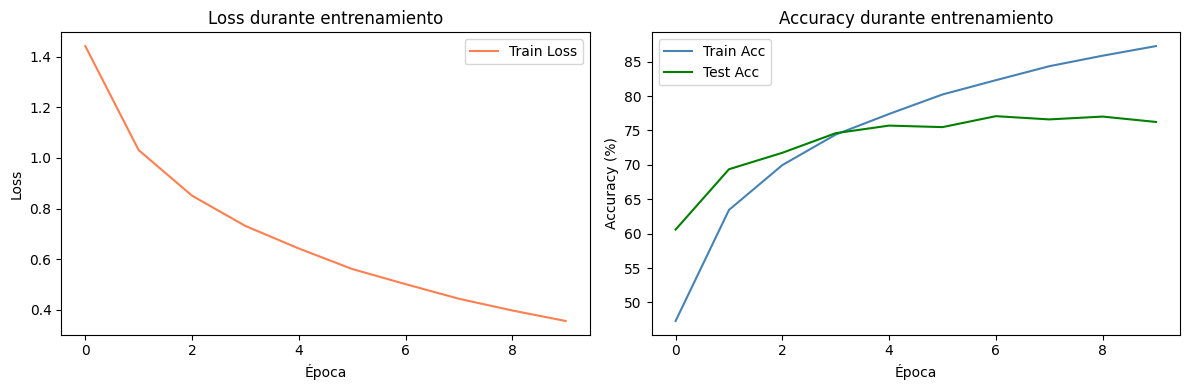

In [7]:
import os

# Guardar modelo
os.makedirs("../models", exist_ok=True)
torch.save(modelo.state_dict(), "../models/cnn_scratch.pth")
print("✓ Modelo guardado en models/cnn_scratch.pth")

# Graficar historial
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Loss
axes[0].plot(historial["train_loss"], label="Train Loss", color="coral")
axes[0].set_title("Loss durante entrenamiento")
axes[0].set_xlabel("Época")
axes[0].set_ylabel("Loss")
axes[0].legend()

# Accuracy
axes[1].plot(historial["train_acc"], label="Train Acc", color="steelblue")
axes[1].plot(historial["test_acc"], label="Test Acc", color="green")
axes[1].set_title("Accuracy durante entrenamiento")
axes[1].set_xlabel("Época")
axes[1].set_ylabel("Accuracy (%)")
axes[1].legend()

plt.tight_layout()
plt.savefig("../data/entrenamiento_cnn.png", dpi=150)
plt.show()

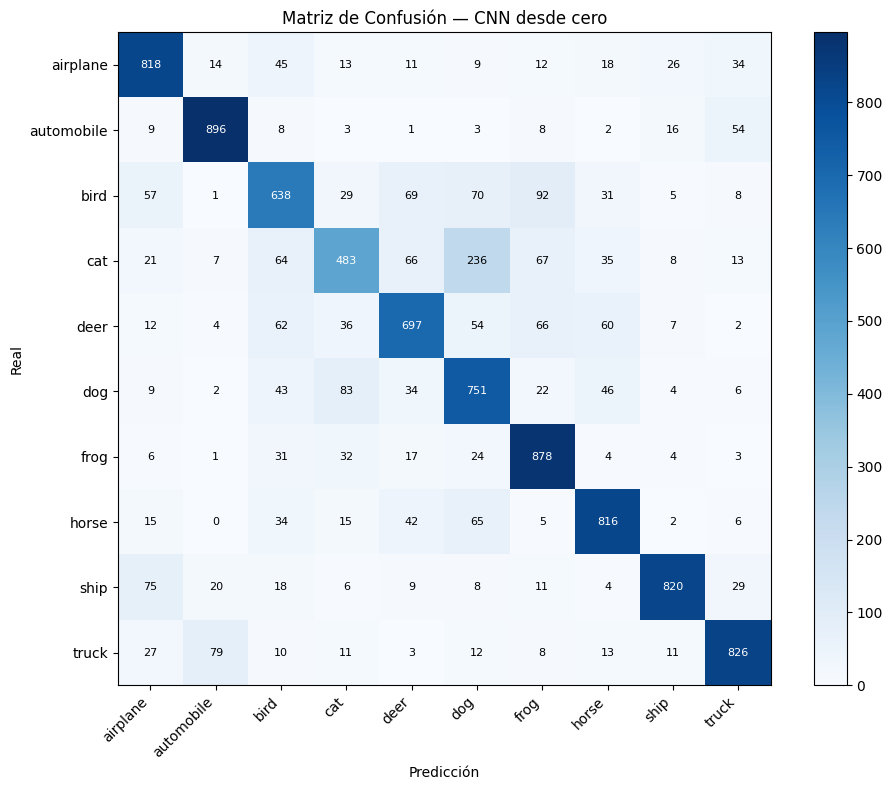


Reporte de clasificación:
              precision    recall  f1-score   support

    airplane       0.78      0.82      0.80      1000
  automobile       0.88      0.90      0.89      1000
        bird       0.67      0.64      0.65      1000
         cat       0.68      0.48      0.56      1000
        deer       0.73      0.70      0.72      1000
         dog       0.61      0.75      0.67      1000
        frog       0.75      0.88      0.81      1000
       horse       0.79      0.82      0.80      1000
        ship       0.91      0.82      0.86      1000
       truck       0.84      0.83      0.83      1000

    accuracy                           0.76     10000
   macro avg       0.76      0.76      0.76     10000
weighted avg       0.76      0.76      0.76     10000



In [8]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

# Obtener predicciones en test
modelo.eval()
todas_predicciones = []
todas_etiquetas = []

with torch.no_grad():
    for imagenes, etiquetas in test_loader:
        imagenes = imagenes.to(dispositivo)
        salidas = modelo(imagenes)
        _, predicciones = salidas.max(1)
        todas_predicciones.extend(predicciones.cpu().numpy())
        todas_etiquetas.extend(etiquetas.numpy())

# Matriz de confusión
cm = confusion_matrix(todas_etiquetas, todas_predicciones)

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(cm, interpolation='nearest', cmap='Blues')
plt.colorbar(im)

ax.set_xticks(range(10))
ax.set_yticks(range(10))
ax.set_xticklabels(clases, rotation=45, ha='right')
ax.set_yticklabels(clases)
ax.set_title("Matriz de Confusión — CNN desde cero")
ax.set_xlabel("Predicción")
ax.set_ylabel("Real")

for i in range(10):
    for j in range(10):
        ax.text(j, i, str(cm[i, j]), ha='center', va='center',
                color='white' if cm[i, j] > cm.max()/2 else 'black', fontsize=8)

plt.tight_layout()
plt.savefig("../data/confusion_matrix_cnn.png", dpi=150)
plt.show()

print("\nReporte de clasificación:")
print(classification_report(todas_etiquetas, todas_predicciones, target_names=clases))